# ANALISIS FAKTOR MALNUTRISI ANAK MENGGUNAKAN DATA SOSIAL EKONOMI

## 1. Data Understanding

In [1]:

# Import Library yang Diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Dataset
df = pd.read_csv('country-wise-average.csv')

# Tampilkan informasi dasar
print("=" * 80)
print("INFORMASI DATASET")
print("=" * 80)
print(f"\nBentuk Dataset: {df.shape}")
print(f"\nBaris pertama:\n{df.head()}")
print(f"\nTipe Data:\n{df.dtypes}")
print(f"\nStatistik Deskriptif:\n{df.describe()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")


INFORMASI DATASET

Bentuk Dataset: (152, 8)

Baris pertama:
       Country  Income Classification  Severe Wasting    Wasting  Overweight  \
0  AFGHANISTAN                    0.0        3.033333  10.350000    5.125000   
1      ALBANIA                    2.0        4.075000   7.760000   20.800000   
2      ALGERIA                    2.0        2.733333   5.942857   12.833333   
3       ANGOLA                    1.0        2.400000   6.933333    2.550000   
4    ARGENTINA                    2.0        0.200000   2.150000   11.125000   

    Stunting  Underweight  U5 Population ('000s)  
0  47.775000    30.375000            4918.561500  
1  24.160000     7.700000             232.859800  
2  19.571429     7.342857            3565.213143  
3  42.633333    23.600000            3980.054000  
4  10.025000     2.600000            3613.651750  

Tipe Data:
Country                      str
Income Classification    float64
Severe Wasting           float64
Wasting                  float64
Overweigh

## 2. Data Preprocessing

In [2]:
# Data Preprocessing
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Copy dataset untuk preprocessing
df_processed = df.copy()

# 1. HANDLING MISSING VALUES
print("\n1. Handling Missing Values")
print(f"Missing values sebelum: \n{df_processed.isnull().sum()}")

# Strategi: Drop rows dengan missing values di kolom target (Stunting)
df_processed = df_processed.dropna(subset=['Stunting'])

# Fill missing values di fitur dengan median
numeric_columns = ['Severe Wasting', 'Wasting', 'Overweight', 'Underweight', 'Income Classification', 'U5 Population (\'000s)']
for col in numeric_columns:
    df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Drop rows yang masih punya NaN di fitur apapun
df_processed = df_processed.dropna(subset=numeric_columns + ['Stunting'])

print(f"\nMissing values sesudah: \n{df_processed.isnull().sum()}")
print(f"Baris yang tersisa: {df_processed.shape[0]}")

# 2. OUTLIER DETECTION (menggunakan IQR method)
print("\n2. Outlier Detection & Handling")
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Identifikasi outliers tapi jangan dihapus agar jumlah data cukup (biarkan natural variation)
outliers_count = 0
for col in ['Stunting', 'Severe Wasting', 'Wasting']:
    outliers = detect_outliers_iqr(df_processed, col)
    outliers_count += outliers.sum()
    print(f"Outliers di '{col}': {outliers.sum()}")

print(f"Total potensi outliers (akan dipertahankan untuk diversitas data): {outliers_count}")

# 3. FEATURE ENGINEERING - Pilih fitur yang relevan
print("\n3. Feature Selection")
X = df_processed[['Severe Wasting', 'Wasting', 'Overweight', 'Underweight', 'Income Classification', 'U5 Population (\'000s)']].copy()
y = df_processed['Stunting'].copy()

print(f"Fitur yang digunakan: {list(X.columns)}")
print(f"Target (Stunting): {y.name}")
print(f"Ukuran X: {X.shape}, Ukuran y: {y.shape}")

# 4. STANDARDISASI DATA
print("\n4. Data Standardisasi")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Sebelum scaling - Mean: {X.mean().values}, Std: {X.std().values}")
print(f"Sesudah scaling - Mean: {X_scaled.mean().values}, Std: {X_scaled.std().values}")
print(f"\nData siap untuk modeling (tanpa NaN): {X_scaled.isnull().sum().sum()} NaN values")
print("\n✓ Data Preprocessing selesai!")


DATA PREPROCESSING

1. Handling Missing Values
Missing values sebelum: 
Country                   0
Income Classification     0
Severe Wasting           12
Wasting                   2
Overweight                3
Stunting                  1
Underweight               2
U5 Population ('000s)     0
dtype: int64

Missing values sesudah: 
Country                  0
Income Classification    0
Severe Wasting           0
Wasting                  0
Overweight               0
Stunting                 0
Underweight              0
U5 Population ('000s)    0
dtype: int64
Baris yang tersisa: 140

2. Outlier Detection & Handling
Outliers di 'Stunting': 0
Outliers di 'Severe Wasting': 3
Outliers di 'Wasting': 3
Total potensi outliers (akan dipertahankan untuk diversitas data): 6

3. Feature Selection
Fitur yang digunakan: ['Severe Wasting', 'Wasting', 'Overweight', 'Underweight', 'Income Classification', "U5 Population ('000s)"]
Target (Stunting): Stunting
Ukuran X: (140, 6), Ukuran y: (140,)

4. Data

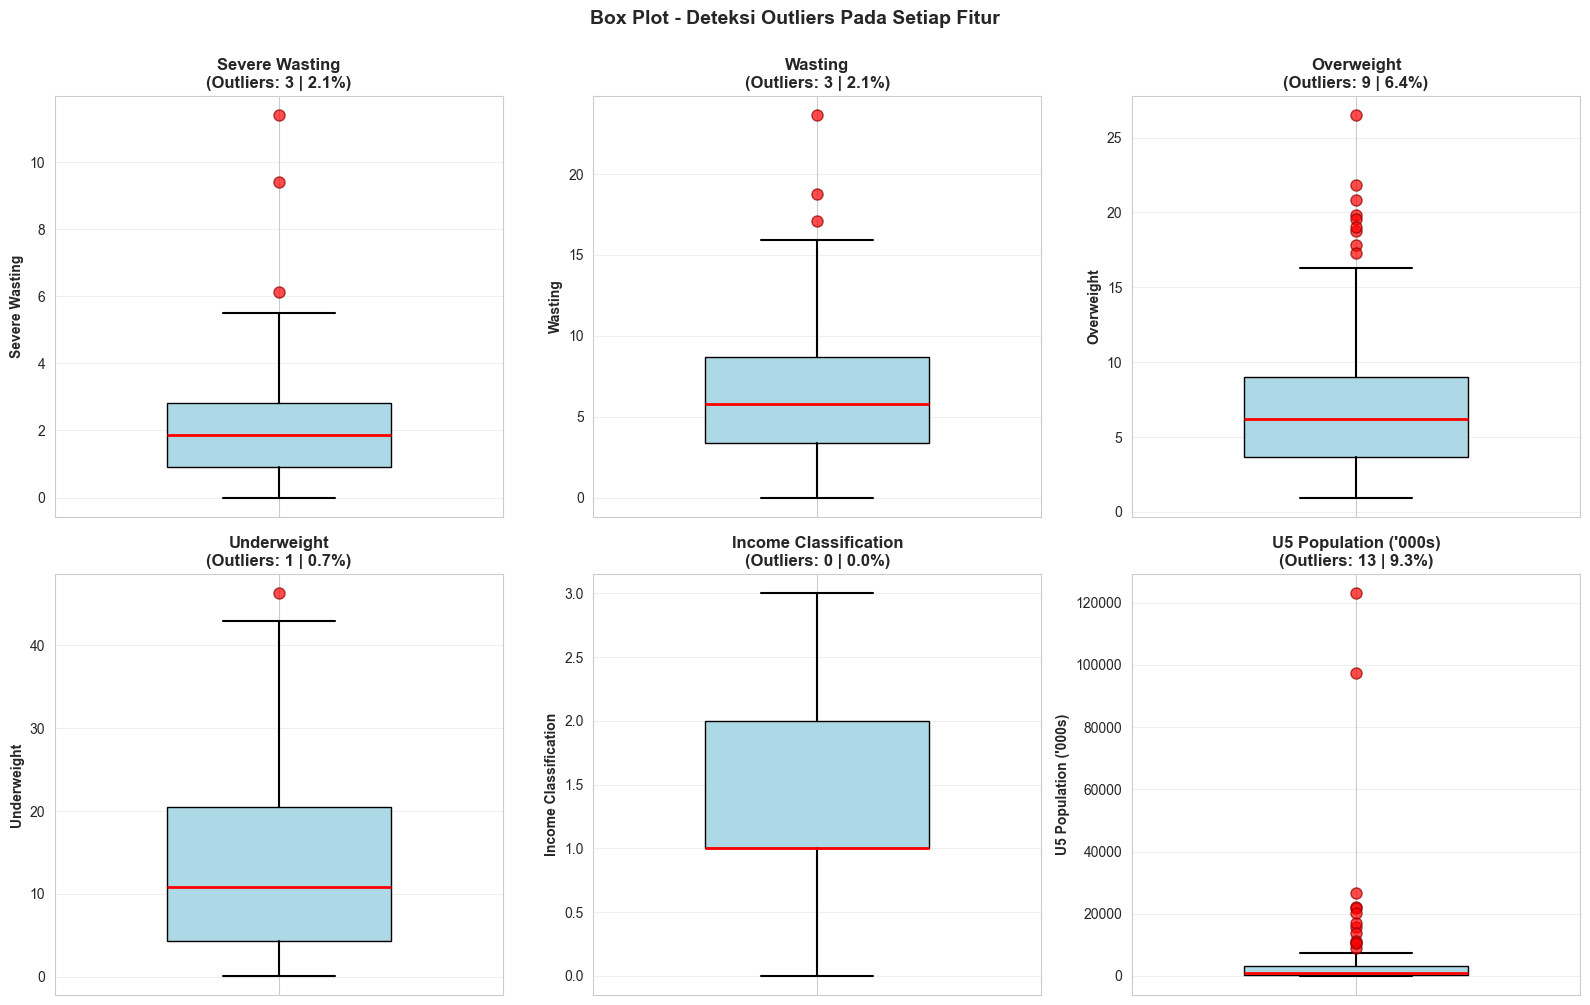

In [24]:
# OUTLIER VISUALIZATION
# Function untuk detect outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# BOX PLOT untuk mendeteksi outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Box Plot - Deteksi Outliers Pada Setiap Fitur', fontsize=14, fontweight='bold', y=1.00)

for idx, col in enumerate(X.columns):
    ax = axes[idx]
    
    # Create box plot
    bp = ax.boxplot(X[col], vert=True, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=8, 
                                  markeredgecolor='darkred', alpha=0.7))
    
    # Count outliers
    outliers = detect_outliers_iqr(X, col)
    outlier_count = outliers.sum()
    outlier_percent = (outlier_count / len(X)) * 100
    
    ax.set_ylabel(col, fontweight='bold')
    ax.set_title(f'{col}\n(Outliers: {outlier_count} | {outlier_percent:.1f}%)', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels([])

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)

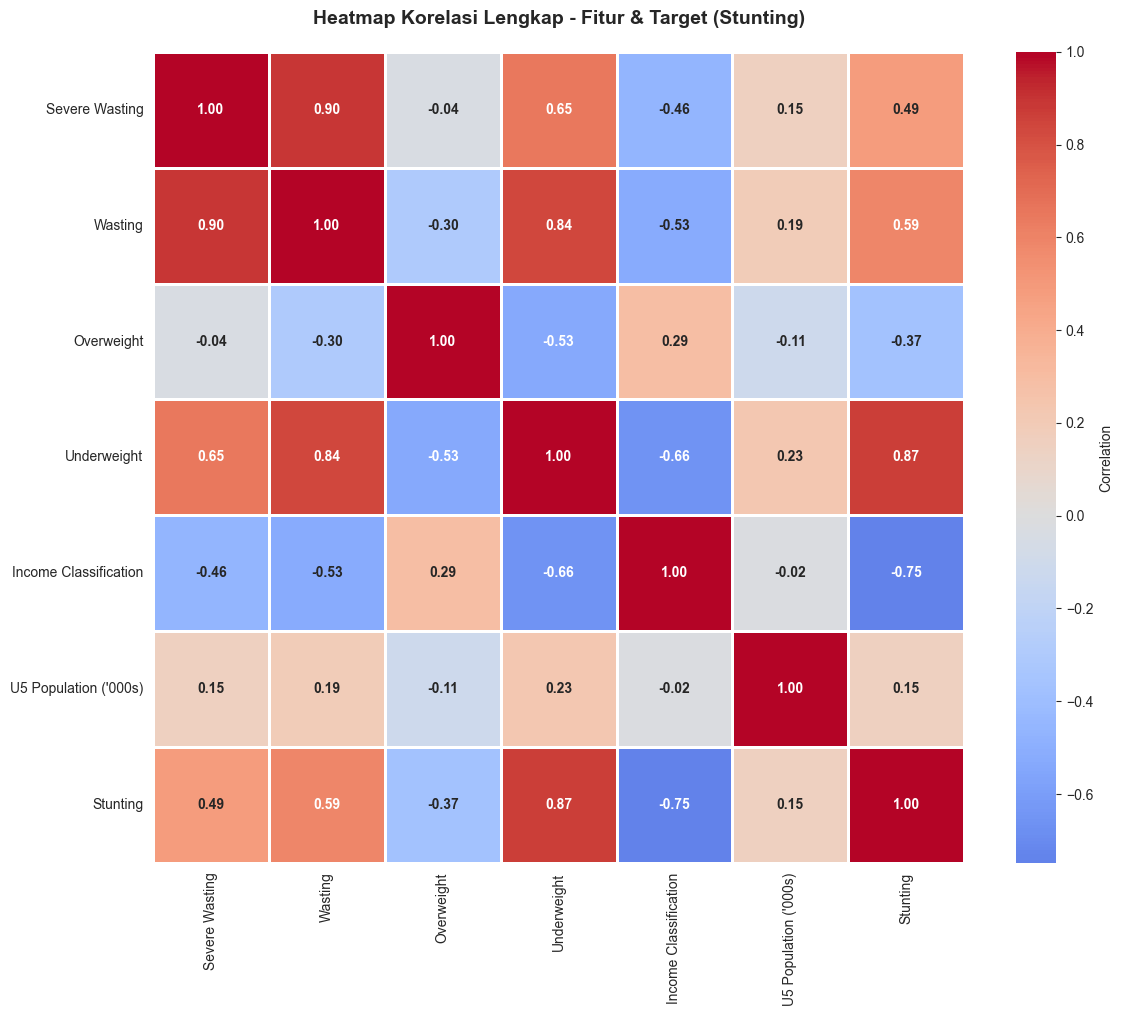


KORELASI FITUR DENGAN TARGET (STUNTING)
Underweight              0.865603
Wasting                  0.589097
Severe Wasting           0.486065
U5 Population ('000s)    0.146733
Overweight              -0.370936
Income Classification   -0.748763

Fitur dengan korelasi tertinggi: Underweight (0.8656)
Fitur dengan korelasi terendah: Income Classification (-0.7488)


In [25]:
# HEATMAP CORRELATION - Include Target Variable
plt.figure(figsize=(12, 10))
# Combine X_scaled with target variable
data_with_target = X_scaled.copy()
data_with_target['Stunting'] = y.values

# Calculate correlation including target
corr = data_with_target.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, linewidths=1, square=True,
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title('Heatmap Korelasi Lengkap - Fitur & Target (Stunting)', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Highlight korelasi dengan target
print("\n" + "=" * 80)
print("KORELASI FITUR DENGAN TARGET (STUNTING)")
print("=" * 80)
target_corr = corr['Stunting'].drop('Stunting').sort_values(ascending=False)
print(target_corr.to_string())
print(f"\nFitur dengan korelasi tertinggi: {target_corr.index[0]} ({target_corr.values[0]:.4f})")
print(f"Fitur dengan korelasi terendah: {target_corr.index[-1]} ({target_corr.values[-1]:.4f})")

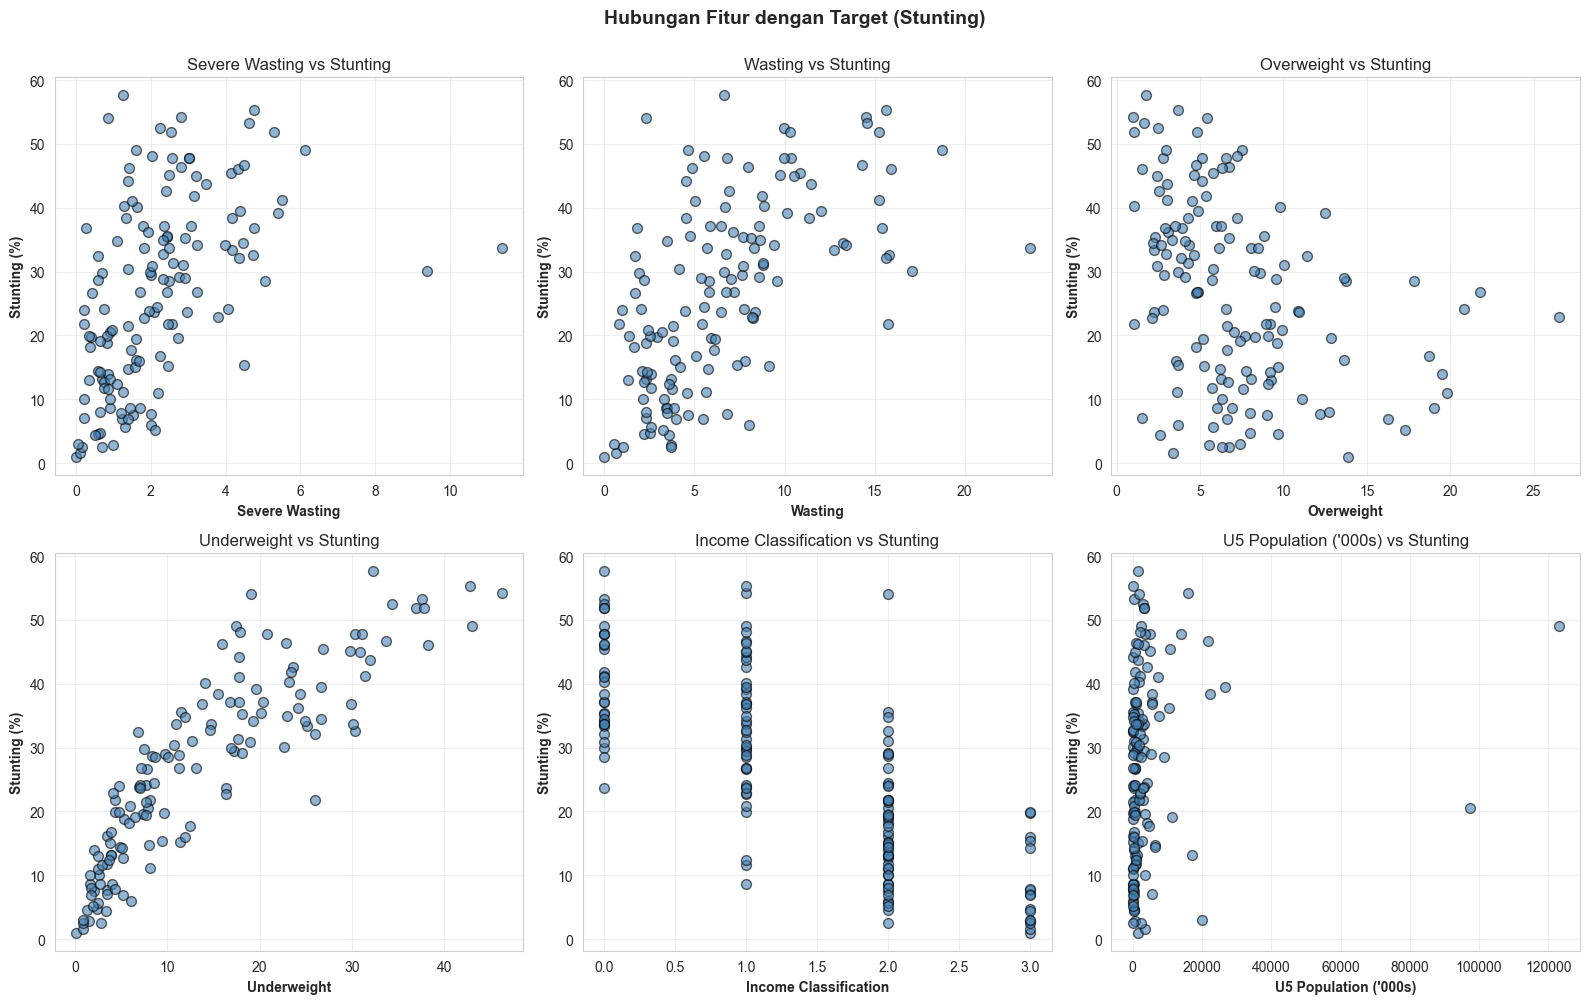

In [20]:
# SCATTER PLOT
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Hubungan Fitur dengan Target (Stunting)', fontsize=14, fontweight='bold', y=1.00)

for idx, col in enumerate(X.columns):
    ax = axes[idx]
    ax.scatter(X[col], y, alpha=0.6, s=50, color='steelblue', edgecolors='black')
    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel('Stunting (%)', fontweight='bold')
    ax.set_title(f'{col} vs Stunting')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Data Splitting



- **70% Training : 30% Testing** 
- **80% Training : 20% Testing** 
- **90% Training : 10% Testing**




## 5. Model Building

In [4]:

# STEP 4: DATA SPLITTING - Prepare 3 train-test ratios
print("\n" + "=" * 80)
print("STEP 4: DATA SPLITTING")
print("=" * 80)

# Definisikan 3 variasi data splitting
train_test_ratios = [
    (0.7, 0.3, "70-30"),
    (0.8, 0.2, "80-20"),
    (0.9, 0.1, "90-10")
]

# Dictionary untuk menyimpan semua splits
data_splits = {}

for train_ratio, test_ratio, ratio_name in train_test_ratios:
    print(f"\n{'='*60}")
    print(f"Data Split: {ratio_name} (Train: {int(train_ratio*100)}%, Test: {int(test_ratio*100)}%)")
    print(f"{'='*60}")
    
    # Splitting data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, 
        test_size=test_ratio, 
        random_state=42
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Testing set: {X_test.shape[0]} samples")
    
    # Simpan split
    data_splits[ratio_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

print("\n✓ Data Splitting selesai untuk 3 rasio!")
print(f"\nData splits tersedia: {list(data_splits.keys())}")

# Initialize models_results dictionary
models_results = {}




STEP 4: DATA SPLITTING

Data Split: 70-30 (Train: 70%, Test: 30%)
Training set: 98 samples
Testing set: 42 samples

Data Split: 80-20 (Train: 80%, Test: 20%)
Training set: 112 samples
Testing set: 28 samples

Data Split: 90-10 (Train: 90%, Test: 10%)
Training set: 126 samples
Testing set: 14 samples

✓ Data Splitting selesai untuk 3 rasio!

Data splits tersedia: ['70-30', '80-20', '90-10']


In [5]:
# STEP 5.1: LINEAR REGRESSION - Train pada 3 data splits
print("\n" + "=" * 80)
print("STEP 5.1: MODEL BUILDING - LINEAR REGRESSION")
print("=" * 80)

models_results['Linear Regression'] = {}

for ratio_name, splits in data_splits.items():
    X_train, X_test = splits['X_train'], splits['X_test']
    y_train, y_test = splits['y_train'], splits['y_test']
    
    print(f"\n{'='*60}")
    print(f"Split: {ratio_name} | Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
    print(f"{'='*60}")
    
    # Build Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr_train = lr_model.predict(X_train)
    y_pred_lr = lr_model.predict(X_test)
    
    # Training Metrics
    lr_r2_train = r2_score(y_train, y_pred_lr_train)
    lr_mae_train = mean_absolute_error(y_train, y_pred_lr_train)
    
    # Test Metrics
    lr_r2 = r2_score(y_test, y_pred_lr)
    lr_mae = mean_absolute_error(y_test, y_pred_lr)
    lr_mse = mean_squared_error(y_test, y_pred_lr)
    lr_rmse = np.sqrt(lr_mse)
    
    gap = abs(lr_r2_train - lr_r2)
    overfitting_status = "✅ No" if gap < 0.02 else ("⚠️ Slight" if gap < 0.07 else "❌ High")
    
    print(f"Train R²: {lr_r2_train:.4f} | Test R²: {lr_r2:.4f} | Gap: {gap:.4f} {overfitting_status}")
    print(f"MAE (Train: {lr_mae_train:.4f}, Test: {lr_mae:.4f}) | RMSE: {lr_rmse:.4f} | R²: {lr_r2:.4f}")
    
    models_results['Linear Regression'][ratio_name] = {
        'model': lr_model,
        'y_pred': y_pred_lr,
        'mae': lr_mae,
        'mse': lr_mse,
        'rmse': lr_rmse,
        'r2': lr_r2,
        'train_r2': lr_r2_train
    }
    
    # Simpan 70-30 split untuk tuning nanti
    if ratio_name == "70-30":
        X_train_70, X_test_70 = X_train, X_test
        y_train_70, y_test_70 = y_train, y_test

print("\n✓ Linear Regression Training selesai untuk 3 splits!")


STEP 5.1: MODEL BUILDING - LINEAR REGRESSION

Split: 70-30 | Train: 98, Test: 42
Train R²: 0.9020 | Test R²: 0.9018 | Gap: 0.0002 ✅ No
MAE (Train: 3.7573, Test: 3.2816) | RMSE: 4.5092 | R²: 0.9018

Split: 80-20 | Train: 112, Test: 28
Train R²: 0.9019 | Test R²: 0.9045 | Gap: 0.0026 ✅ No
MAE (Train: 3.6737, Test: 3.1420) | RMSE: 4.4090 | R²: 0.9045

Split: 90-10 | Train: 126, Test: 14
Train R²: 0.8979 | Test R²: 0.9364 | Gap: 0.0385 ⚠️ Slight
MAE (Train: 3.6950, Test: 2.5703) | RMSE: 3.9050 | R²: 0.9364

✓ Linear Regression Training selesai untuk 3 splits!


In [6]:
# STEP 5.2: RANDOM FOREST - Train pada 3 data splits
print("\n" + "=" * 80)
print("STEP 5.2: MODEL BUILDING - RANDOM FOREST REGRESSOR")
print("=" * 80)

models_results['Random Forest'] = {}

for ratio_name, splits in data_splits.items():
    X_train, X_test = splits['X_train'], splits['X_test']
    y_train, y_test = splits['y_train'], splits['y_test']
    
    print(f"\n{'='*60}")
    print(f"Split: {ratio_name} | Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
    print(f"{'='*60}")
    
    # Build Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
    rf_model.fit(X_train, y_train)
    y_pred_rf_train = rf_model.predict(X_train)
    y_pred_rf = rf_model.predict(X_test)
    
    # Training Metrics
    rf_r2_train = r2_score(y_train, y_pred_rf_train)
    rf_mae_train = mean_absolute_error(y_train, y_pred_rf_train)
    
    # Test Metrics
    rf_r2 = r2_score(y_test, y_pred_rf)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_mse = mean_squared_error(y_test, y_pred_rf)
    rf_rmse = np.sqrt(rf_mse)
    
    gap = abs(rf_r2_train - rf_r2)
    overfitting_status = "✅ No" if gap < 0.02 else ("⚠️ Slight" if gap < 0.07 else "❌ High")
    
    print(f"Train R²: {rf_r2_train:.4f} | Test R²: {rf_r2:.4f} | Gap: {gap:.4f} {overfitting_status}")
    print(f"MAE (Train: {rf_mae_train:.4f}, Test: {rf_mae:.4f}) | RMSE: {rf_rmse:.4f} | R²: {rf_r2:.4f}")
    
    models_results['Random Forest'][ratio_name] = {
        'model': rf_model,
        'y_pred': y_pred_rf,
        'mae': rf_mae,
        'mse': rf_mse,
        'rmse': rf_rmse,
        'r2': rf_r2,
        'train_r2': rf_r2_train
    }

print("\n✓ Random Forest Training selesai untuk 3 splits!")


STEP 5.2: MODEL BUILDING - RANDOM FOREST REGRESSOR

Split: 70-30 | Train: 98, Test: 42
Train R²: 0.9775 | Test R²: 0.9008 | Gap: 0.0768 ❌ High
MAE (Train: 1.6776, Test: 3.8430) | RMSE: 4.5327 | R²: 0.9008

Split: 80-20 | Train: 112, Test: 28
Train R²: 0.9783 | Test R²: 0.9131 | Gap: 0.0652 ⚠️ Slight
MAE (Train: 1.7000, Test: 3.4140) | RMSE: 4.2071 | R²: 0.9131

Split: 90-10 | Train: 126, Test: 14
Train R²: 0.9808 | Test R²: 0.9385 | Gap: 0.0423 ⚠️ Slight
MAE (Train: 1.5450, Test: 3.4620) | RMSE: 3.8389 | R²: 0.9385

✓ Random Forest Training selesai untuk 3 splits!


In [7]:
# STEP 5.3: GRADIENT BOOSTING - Train pada 3 data splits
print("\n" + "=" * 80)
print("STEP 5.3: MODEL BUILDING - GRADIENT BOOSTING REGRESSOR")
print("=" * 80)

models_results['Gradient Boosting'] = {}

for ratio_name, splits in data_splits.items():
    X_train, X_test = splits['X_train'], splits['X_test']
    y_train, y_test = splits['y_train'], splits['y_test']
    
    print(f"\n{'='*60}")
    print(f"Split: {ratio_name} | Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
    print(f"{'='*60}")
    
    # Build Gradient Boosting
    gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    gb_model.fit(X_train, y_train)
    y_pred_gb_train = gb_model.predict(X_train)
    y_pred_gb = gb_model.predict(X_test)
    
    # Training Metrics
    gb_r2_train = r2_score(y_train, y_pred_gb_train)
    gb_mae_train = mean_absolute_error(y_train, y_pred_gb_train)
    
    # Test Metrics
    gb_r2 = r2_score(y_test, y_pred_gb)
    gb_mae = mean_absolute_error(y_test, y_pred_gb)
    gb_mse = mean_squared_error(y_test, y_pred_gb)
    gb_rmse = np.sqrt(gb_mse)
    
    gap = abs(gb_r2_train - gb_r2)
    overfitting_status = "✅ No" if gap < 0.02 else ("⚠️ Slight" if gap < 0.07 else "❌ High")
    
    print(f"Train R²: {gb_r2_train:.4f} | Test R²: {gb_r2:.4f} | Gap: {gap:.4f} {overfitting_status}")
    print(f"MAE (Train: {gb_mae_train:.4f}, Test: {gb_mae:.4f}) | RMSE: {gb_rmse:.4f} | R²: {gb_r2:.4f}")
    
    models_results['Gradient Boosting'][ratio_name] = {
        'model': gb_model,
        'y_pred': y_pred_gb,
        'mae': gb_mae,
        'mse': gb_mse,
        'rmse': gb_rmse,
        'r2': gb_r2,
        'train_r2': gb_r2_train
    }

print("\n✓ Gradient Boosting Training pada 3 splits completed!")
print("📊 Lihat markdown summary di atas untuk analisis Train vs Test R² detail")


STEP 5.3: MODEL BUILDING - GRADIENT BOOSTING REGRESSOR

Split: 70-30 | Train: 98, Test: 42
Train R²: 1.0000 | Test R²: 0.8551 | Gap: 0.1449 ❌ High
MAE (Train: 0.0207, Test: 4.4344) | RMSE: 5.4766 | R²: 0.8551

Split: 80-20 | Train: 112, Test: 28
Train R²: 1.0000 | Test R²: 0.8863 | Gap: 0.1137 ❌ High
MAE (Train: 0.0441, Test: 3.8120) | RMSE: 4.8108 | R²: 0.8863

Split: 90-10 | Train: 126, Test: 14
Train R²: 1.0000 | Test R²: 0.9267 | Gap: 0.0732 ❌ High
MAE (Train: 0.0828, Test: 3.2144) | RMSE: 4.1907 | R²: 0.9267

✓ Gradient Boosting Training pada 3 splits completed!
📊 Lihat markdown summary di atas untuk analisis Train vs Test R² detail


## 6. Hyperparameter Tuning

In [26]:

# Hyperparameter Tuning menggunakan GridSearchCV (pada split 70-30)
print("\n" + "=" * 80)
print("STEP 6: HYPERPARAMETER TUNING")
print("=" * 80)
print("Menggunakan GridSearchCV pada split 70-30")

tuned_models = {}

# ===== TUNING 1: RANDOM FOREST =====
print(f"\n1. Tuning Random Forest Regressor")
print("-" * 60)

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train_70, y_train_70)
y_pred_rf_tuned = rf_grid.predict(X_test_70)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")
print(f"Test Set Performance:")
print(f"   MAE: {mean_absolute_error(y_test_70, y_pred_rf_tuned):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test_70, y_pred_rf_tuned)):.4f}")
print(f"   R²: {r2_score(y_test_70, y_pred_rf_tuned):.4f}")

tuned_models['Random Forest'] = {
    'model': rf_grid.best_estimator_,
    'y_pred': y_pred_rf_tuned,
    'mae': mean_absolute_error(y_test_70, y_pred_rf_tuned),
    'rmse': np.sqrt(mean_squared_error(y_test_70, y_pred_rf_tuned)),
    'r2': r2_score(y_test_70, y_pred_rf_tuned)
}

# ===== TUNING 2: GRADIENT BOOSTING =====
print(f"\n2. Tuning Gradient Boosting Regressor")
print("-" * 60)

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

gb_grid.fit(X_train_70, y_train_70)
y_pred_gb_tuned = gb_grid.predict(X_test_70)

print(f"Best Parameters: {gb_grid.best_params_}")
print(f"Best CV Score: {gb_grid.best_score_:.4f}")
print(f"Test Set Performance:")
print(f"   MAE: {mean_absolute_error(y_test_70, y_pred_gb_tuned):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(y_test_70, y_pred_gb_tuned)):.4f}")
print(f"   R²: {r2_score(y_test_70, y_pred_gb_tuned):.4f}")

tuned_models['Gradient Boosting'] = {
    'model': gb_grid.best_estimator_,
    'y_pred': y_pred_gb_tuned,
    'mae': mean_absolute_error(y_test_70, y_pred_gb_tuned),
    'rmse': np.sqrt(mean_squared_error(y_test_70, y_pred_gb_tuned)),
    'r2': r2_score(y_test_70, y_pred_gb_tuned)
}



STEP 6: HYPERPARAMETER TUNING
Menggunakan GridSearchCV pada split 70-30

1. Tuning Random Forest Regressor
------------------------------------------------------------
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.8083
Test Set Performance:
   MAE: 3.9831
   RMSE: 4.5978
   R²: 0.8979

2. Tuning Gradient Boosting Regressor
------------------------------------------------------------
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Score: 0.8233
Test Set Performance:
   MAE: 3.4889
   RMSE: 4.3097
   R²: 0.9103


## 7.  Model Evaluation

In [9]:
# Model Evaluation
print("\n" + "=" * 80)
print("STEP 7: MODEL EVALUATION")
print("=" * 80)

# Evaluasi model yang di-tune pada split 70-30
print(f"\nEvaluasi Model Tuned (Split 70-30):")
print("-" * 60)

evaluation_results = {}

for model_name, model_data in tuned_models.items():
    y_pred = model_data['y_pred']
    mae = model_data['mae']
    rmse = model_data['rmse']
    r2 = model_data['r2']
    
    print(f"\n{model_name}:")
    print(f"  MAE (Mean Absolute Error):  {mae:.4f}%")
    print(f"  RMSE (Root Mean Square Error): {rmse:.4f}%")
    print(f"  R² Score: {r2:.4f}")
    
    evaluation_results[model_name] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    
    # Tambahkan Linear Regression untuk perbandingan
    if model_name == 'Gradient Boosting':
        lr_y_pred = models_results['Linear Regression']['70-30']['y_pred']
        lr_mae = models_results['Linear Regression']['70-30']['mae']
        lr_rmse = models_results['Linear Regression']['70-30']['rmse']
        lr_r2 = models_results['Linear Regression']['70-30']['r2']
        
        print(f"\nLinear Regression:")
        print(f"  MAE (Mean Absolute Error):  {lr_mae:.4f}%")
        print(f"  RMSE (Root Mean Square Error): {lr_rmse:.4f}%")
        print(f"  R² Score: {lr_r2:.4f}")
        
        evaluation_results['Linear Regression'] = {'mae': lr_mae, 'rmse': lr_rmse, 'r2': lr_r2}


STEP 7: MODEL EVALUATION

Evaluasi Model Tuned (Split 70-30):
------------------------------------------------------------

Random Forest:
  MAE (Mean Absolute Error):  3.9831%
  RMSE (Root Mean Square Error): 4.5978%
  R² Score: 0.8979

Gradient Boosting:
  MAE (Mean Absolute Error):  3.4889%
  RMSE (Root Mean Square Error): 4.3097%
  R² Score: 0.9103

Linear Regression:
  MAE (Mean Absolute Error):  3.2816%
  RMSE (Root Mean Square Error): 4.5092%
  R² Score: 0.9018


## 8. Model Comparison

In [17]:
# Model Comparison
print("\n" + "=" * 80)
print("STEP 8: MODEL COMPARISON")
print("=" * 80)

# Buat dictionary untuk bar chart data - approach yang lebih simple
chart_data = {
    'Linear Regression': {},
    'Random Forest': {},
    'Gradient Boosting': {}
}

# Populate chart_data dari models_results (structure: models_results[model][ratio])
for model_name, ratios_dict in models_results.items():
    for ratio_name, metrics in ratios_dict.items():
        chart_data[model_name][ratio_name] = metrics['r2']

print("\nData untuk Chart:")
print(chart_data)

# Buat tabel perbandingan untuk semua rasio splitting
comparison_data = []

# Build dari models_results dengan struktur yang benar
for model_name, ratios_dict in models_results.items():
    for ratio_name, metrics in ratios_dict.items():
        comparison_data.append({
            'Data Split': ratio_name,
            'Model': model_name,
            'MAE': metrics['mae'],
            'MSE': metrics['mse'],
            'RMSE': metrics['rmse'],
            'R² Score': metrics['r2']
        })

# Tambahkan hasil tuning (70-30)
for model_name, metrics in tuned_models.items():
    comparison_data.append({
        'Data Split': '70-30 (Tuned)',
        'Model': model_name,
        'MAE': metrics['mae'],
        'MSE': metrics['rmse'] ** 2,
        'RMSE': metrics['rmse'],
        'R² Score': metrics['r2']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nTabel Perbandingan Semua Model:")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Analisis model terbaik
print("\n" + "=" * 80)
print("ANALISIS HASIL:")
print("=" * 80)

best_r2_idx = comparison_df['R² Score'].idxmax()
best_model = comparison_df.loc[best_r2_idx]

print(f"\n✓ Model Terbaik:")
print(f"  Split: {best_model['Data Split']}")
print(f"  Model: {best_model['Model']}")
print(f"  R² Score: {best_model['R² Score']:.4f}")
print(f"  MAE: {best_model['MAE']:.4f}%")
print(f"  RMSE: {best_model['RMSE']:.4f}%")

# Feature Importance dari Random Forest
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS:")
print("=" * 80)

rf_tuned = tuned_models['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance dari Random Forest (Tuned):")
print(feature_importance.to_string(index=False))


STEP 8: MODEL COMPARISON

Data untuk Chart:
{'Linear Regression': {'70-30': 0.9017994925717663, '80-20': 0.9045084494161839, '90-10': 0.93638169413535}, 'Random Forest': {'70-30': 0.9007727832768337, '80-20': 0.9130531385286667, '90-10': 0.9385159221890117}, 'Gradient Boosting': {'70-30': 0.8551464601195459, '80-20': 0.8863096885933428, '90-10': 0.9267329867488958}}

Tabel Perbandingan Semua Model:
   Data Split             Model      MAE       MSE     RMSE  R² Score
        70-30 Linear Regression 3.281608 20.333099 4.509224  0.901799
        80-20 Linear Regression 3.142033 19.439047 4.408973  0.904508
        90-10 Linear Regression 2.570332 15.249019 3.904999  0.936382
        70-30     Random Forest 3.843020 20.545687 4.532735  0.900773
        80-20     Random Forest 3.413990 17.699619 4.207092  0.913053
        90-10     Random Forest 3.462024 14.737454 3.838939  0.938516
        70-30 Gradient Boosting 4.434402 29.992935 5.476581  0.855146
        80-20 Gradient Boosting 3.811

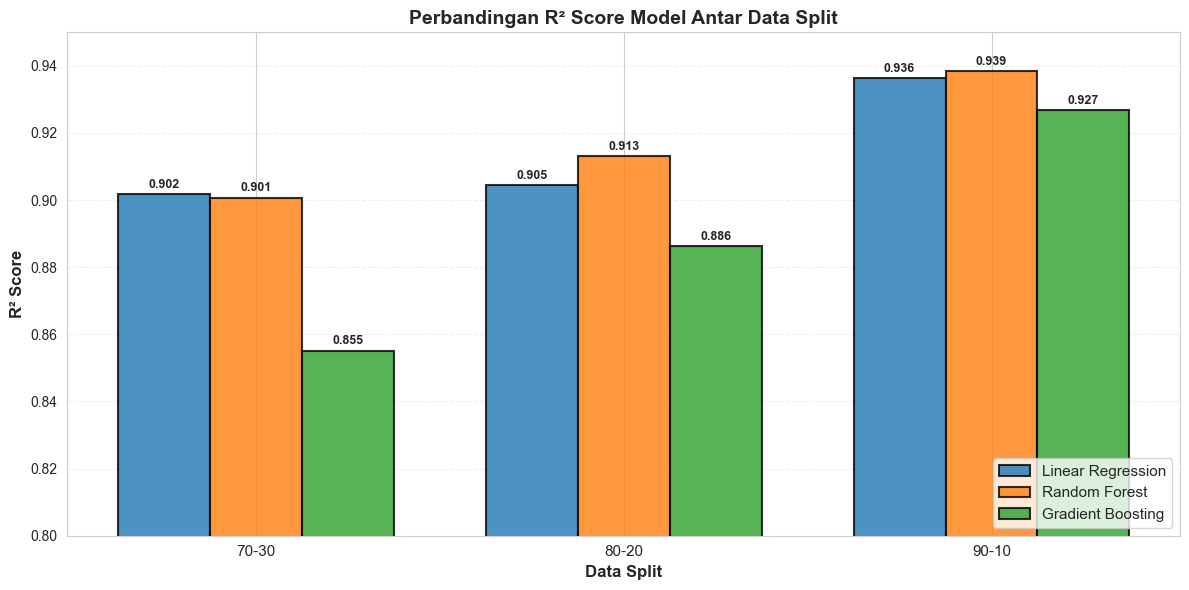

In [22]:
# MODEL COMPARISON - R² SCORE ACROSS SPLITS
fig, ax = plt.subplots(figsize=(12, 6))

models_list = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
splits = ['70-30', '80-20', '90-10']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

x = np.arange(len(splits))
width = 0.25

for i, model in enumerate(models_list):
    r2_values = [chart_data[model].get(split, 0) for split in splits]
    bars = ax.bar(x + i*width, r2_values, width, label=model, color=colors[i], 
                  edgecolor='black', alpha=0.8, linewidth=1.5)
    for bar, val in zip(bars, r2_values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
               f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Data Split', fontweight='bold', fontsize=12)
ax.set_ylabel('R² Score', fontweight='bold', fontsize=12)
ax.set_title('Perbandingan R² Score Model Antar Data Split', fontweight='bold', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(splits, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim([0.80, 0.95])

plt.tight_layout()
plt.show()